# Deep Learning for Joint Beamforming & Power Allocation in Multi-User MISO




**System Model:**  
A base station with $N_t$ antennas simultaneously serves $K$ single-antenna users.  
Received signal at user $k$:
$$y_k = \mathbf{h}_k^H \mathbf{w}_k \sqrt{p_k}\, s_k + \sum_{j \neq k} \mathbf{h}_k^H \mathbf{w}_j \sqrt{p_j}\, s_j + n_k$$

**Goal:** Train a neural network to jointly learn:
- Beamforming directions $\mathbf{w}_k \in \mathbb{C}^{N_t}$ (unit-norm)
- Power allocation $p_k \geq 0$ with $\sum_k p_k \leq P_{\max}$

maximizing the system **sum-rate**:
$$R_{\text{sum}} = \sum_{k=1}^{K} \log_2\!\left(1 + \text{SINR}_k\right)$$

## 1. Import Libraries and Setup

In [ ]:
# ============================================================
# Import Required Libraries
# ============================================================

import torch                     # Deep learning framework
import torch.nn as nn           # Neural network module
import torch.optim as optim     # Optimization algorithms

import numpy as np              # Numerical computations

import matplotlib.pyplot as plt # Plotting graphs
import matplotlib.gridspec as gridspec
from matplotlib.patches import Circle

import warnings
warnings.filterwarnings('ignore')  # Ignore warnings for clean output


# ============================================================
# Device Configuration (GPU / CPU)
# ============================================================

# Check if GPU is available, else use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Print device details
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

Device: cuda
PyTorch version: 2.10.0+cu128


## 2. System Parameters

In [ ]:
# ── System Parameters ──────────────────────────────────────────────────────
Nt    = 4          # Number of transmit antennas at base station
K     = 3          # Number of single-antenna users
Pmax  = 1.0        # Maximum total transmit power (normalized)
sigma2 = 1e-2      # Noise variance (sigma^2) per user

# ── Training Parameters ────────────────────────────────────────────────────
NUM_EPOCHS      = 500          # Total training epochs
BATCH_SIZE      = 256          # Channels per mini-batch
LEARNING_RATE   = 1e-3         # Adam learning rate
HIDDEN_DIM      = 256          # Neurons per hidden layer
NUM_HIDDEN      = 3            # Number of hidden layers
LR_DECAY_STEP   = 100          # StepLR: decay every N epochs
LR_DECAY_GAMMA  = 0.5          # StepLR: multiply LR by this factor

# ── Input / Output Dimensions ──────────────────────────────────────────────
# Input: vectorized complex channel H of shape (K, Nt) → real+imag → 2*K*Nt
INPUT_DIM  = 2 * K * Nt
# Output: K beamforming vectors (each Nt complex → 2*Nt real) + K log-powers
OUTPUT_DIM = 2 * K * Nt + K

print(f'MISO system: {Nt} antennas, {K} users')
print(f'Input dim : {INPUT_DIM}   (real+imag of H)')
print(f'Output dim: {OUTPUT_DIM}  ({K} beams × 2×{Nt} + {K} powers)')

MISO system: 4 antennas, 3 users
Input dim : 24   (real+imag of H)
Output dim: 27  (3 beams × 2×4 + 3 powers)


## 3. Channel Generation

In [ ]:
def generate_channel(batch_size: int, K: int, Nt: int) -> torch.Tensor:
    """
    Generate IID Rayleigh fading channels H ~ CN(0, I).

    Returns
    -------
    H_real : Tensor of shape (batch, 2*K*Nt)
        Concatenated real and imaginary parts of the channel matrix,
        suitable as NN input.
    H_cplx : Tensor of shape (batch, K, Nt)  [complex64]
        Complex channel matrix for SINR computation.
    """
    # Real and imaginary parts ~ N(0, 0.5) so |h_kn|^2 ~ Exp(1)
    H_re = torch.randn(batch_size, K, Nt, device=device) / np.sqrt(2)
    H_im = torch.randn(batch_size, K, Nt, device=device) / np.sqrt(2)

    H_cplx = torch.complex(H_re, H_im)          # (batch, K, Nt)
    H_real  = torch.cat([H_re.flatten(1), H_im.flatten(1)], dim=1)  # (batch, 2KNt)

    return H_real, H_cplx


# Quick sanity check
h_in, h_cx = generate_channel(4, K, Nt)
print(f'NN input shape  : {h_in.shape}')   # (4, 2*K*Nt)
print(f'Complex H shape : {h_cx.shape}')   # (4, K, Nt)

NN input shape  : torch.Size([4, 24])
Complex H shape : torch.Size([4, 3, 4])


## 4. Neural Network Model

In [ ]:
class BeamformingNet(nn.Module):
    """
    Fully-connected network for joint beamforming and power allocation.

    Architecture
    ------------
    Input  → [FC → BN → ReLU] × num_hidden → FC → split output
                                                        ├─ Beam head : 2*K*Nt  (real+imag of K beamforming vectors)
                                                        └─ Power head: K       (log-powers, softmax-normalized)

    Forward output
    --------------
    beams  : Tensor (batch, K, Nt)  [complex64]  — unit-norm beamforming vectors
    powers : Tensor (batch, K)      [float32]    — per-user power (sum ≤ Pmax)
    """

    def __init__(self, input_dim, hidden_dim, num_hidden, K, Nt, Pmax):
        super().__init__()
        self.K    = K
        self.Nt   = Nt
        self.Pmax = Pmax

        # ── Shared backbone ────────────────────────────────────────────────
        layers = []
        in_dim = input_dim
        for _ in range(num_hidden):
            layers += [
                nn.Linear(in_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(inplace=True),
            ]
            in_dim = hidden_dim
        self.backbone = nn.Sequential(*layers)

        # ── Beamforming head ───────────────────────────────────────────────
        # Outputs 2*K*Nt values (real & imaginary parts of K vectors of length Nt)
        self.beam_head = nn.Linear(hidden_dim, 2 * K * Nt)

        # ── Power allocation head ─────────────────────────────────────────
        # Outputs K log-power logits; softmax gives water-filling-like allocation
        self.power_head = nn.Linear(hidden_dim, K)

        self._init_weights()

    def _init_weights(self):
        """Xavier uniform init for all linear layers."""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, h_real):
        """
        Parameters
        ----------
        h_real : Tensor (batch, 2*K*Nt)   — real+imag channel features

        Returns
        -------
        beams  : Tensor (batch, K, Nt) complex
        powers : Tensor (batch, K)     real
        """
        feat = self.backbone(h_real)                        # (batch, hidden)

        # ── Beamforming ────────────────────────────────────────────────────
        b_raw = self.beam_head(feat)                        # (batch, 2*K*Nt)
        b_raw = b_raw.view(-1, self.K, 2, self.Nt)         # (batch, K, 2, Nt)
        w_re  = b_raw[:, :, 0, :]                           # (batch, K, Nt)
        w_im  = b_raw[:, :, 1, :]                           # (batch, K, Nt)
        w_cplx = torch.complex(w_re, w_im)                  # (batch, K, Nt)

        # Normalize each beamforming vector to unit norm  ||w_k|| = 1
        w_norm = w_cplx.norm(dim=2, keepdim=True).clamp(min=1e-8)
        beams  = w_cplx / w_norm                            # (batch, K, Nt)

        # ── Power allocation ───────────────────────────────────────────────
        p_logits = self.power_head(feat)                    # (batch, K)
        # Softmax → fractions summing to 1, then scale by K*Pmax
        # (K*Pmax budget lets each user get up to Pmax on average)
        p_frac   = torch.softmax(p_logits, dim=1)           # (batch, K)
        powers   = p_frac * self.K * self.Pmax              # (batch, K)

        return beams, powers


# Instantiate and move to device
model = BeamformingNet(
    input_dim  = INPUT_DIM,
    hidden_dim = HIDDEN_DIM,
    num_hidden = NUM_HIDDEN,
    K=K, Nt=Nt, Pmax=Pmax
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTrainable parameters: {total_params:,}')

BeamformingNet(
  (backbone): Sequential(
    (0): Linear(in_features=24, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
  )
  (beam_head): Linear(in_features=256, out_features=24, bias=True)
  (power_head): Linear(in_features=256, out_features=3, bias=True)
)

Trainable parameters: 146,459


## 5. SINR & Sum-Rate Loss

In [ ]:
def compute_sinr(H_cplx, beams, powers, sigma2):
    """
    Compute SINR for every user.

    Parameters
    ----------
    H_cplx : Tensor (batch, K, Nt)  complex   — channel matrix
    beams  : Tensor (batch, K, Nt)  complex   — unit-norm beamforming vectors
    powers : Tensor (batch, K)      real      — per-user transmit power
    sigma2 : float                            — noise variance

    Returns
    -------
    sinr : Tensor (batch, K)  real
    """
    # Effective channel gain: |h_k^H w_j|^2  →  shape (batch, K_rx, K_tx)
    # H_cplx[:, k, :]  is h_k  (row vector of length Nt)
    # beams[:, j, :]   is w_j  (beamforming vector for user j)

    # Inner product h_k^H w_j = sum_n  conj(h_k[n]) * w_j[n]
    # Vectorized over all (k, j) pairs:
    #   H_cplx : (batch, K, Nt)  →  conj → (batch, K_rx, Nt)
    #   beams  : (batch, K, Nt)  →  permute → (batch, Nt, K_tx)
    # matmul → (batch, K_rx, K_tx)  then |·|^2

    gains = torch.matmul(
        H_cplx.conj(),                          # (batch, K, Nt)
        beams.permute(0, 2, 1)                  # (batch, Nt, K)
    ).abs() ** 2                                # (batch, K_rx, K_tx)

    # Signal power for user k: p_k * |h_k^H w_k|^2
    signal = powers * gains.diagonal(dim1=1, dim2=2)   # (batch, K)

    # Interference: sum_{j != k} p_j * |h_k^H w_j|^2
    # Total received power for user k from all beams:
    total = (powers.unsqueeze(1) * gains).sum(dim=2)   # (batch, K)
    interf = total - signal                             # (batch, K)

    sinr = signal / (interf + sigma2)                  # (batch, K)
    return sinr


def sum_rate_loss(H_cplx, beams, powers, sigma2):
    """
    Negative sum-rate (minimized by gradient descent = maximizing sum-rate).

    R_sum = sum_k  log2(1 + SINR_k)
    Loss  = -mean_batch[ R_sum ]
    """
    sinr     = compute_sinr(H_cplx, beams, powers, sigma2)  # (batch, K)
    rates    = torch.log2(1.0 + sinr)                        # (batch, K)
    sum_rate = rates.sum(dim=1)                              # (batch,)
    loss     = -sum_rate.mean()                              # scalar
    return loss, sum_rate.mean().item()


# Sanity check
with torch.no_grad():
    h_in, h_cx = generate_channel(8, K, Nt)
    bms, pws   = model(h_in)
    loss_, sr_ = sum_rate_loss(h_cx, bms, pws, sigma2)
    print(f'Initial sum-rate (random net): {sr_:.4f} bps/Hz')
    print(f'Power per user (first sample): {pws[0].cpu().numpy()}')
    print(f'Beam norms     (first sample): {bms[0].norm(dim=1).cpu().numpy()}')

Initial sum-rate (random net): 2.0988 bps/Hz
Power per user (first sample): [0.8092483 0.7607907 1.429961 ]
Beam norms     (first sample): [0.99999994 0.99999994 1.        ]


## 6. Training Loop

In [ ]:
# ── Optimizer & Scheduler ──────────────────────────────────────────────────
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(
    optimizer, step_size=LR_DECAY_STEP, gamma=LR_DECAY_GAMMA
)

# ── History buffers ────────────────────────────────────────────────────────
loss_history      = []
sum_rate_history  = []
lr_history        = []

# ── Training ───────────────────────────────────────────────────────────────
print(f'{'Epoch':>6}  {'Loss':>10}  {'Sum-Rate':>12}  {'LR':>12}')
print('-' * 48)

model.train()
for epoch in range(1, NUM_EPOCHS + 1):

    # Fresh random channel batch each epoch (online learning)
    h_real, h_cplx = generate_channel(BATCH_SIZE, K, Nt)

    # ── Forward pass ──────────────────────────────────────────────────────
    beams, powers = model(h_real)

    # ── Loss = negative sum-rate ───────────────────────────────────────────
    loss, sr = sum_rate_loss(h_cplx, beams, powers, sigma2)

    # ── Backward pass & parameter update ──────────────────────────────────
    optimizer.zero_grad()
    loss.backward()                          # backpropagate gradients
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)  # gradient clipping
    optimizer.step()                         # update weights
    scheduler.step()                         # decay learning rate

    # ── Record ────────────────────────────────────────────────────────────
    loss_history.append(loss.item())
    sum_rate_history.append(sr)
    lr_history.append(scheduler.get_last_lr()[0])

    if epoch % 50 == 0 or epoch == 1:
        print(f'{epoch:>6}  {loss.item():>10.4f}  {sr:>12.4f}  {lr_history[-1]:>12.2e}')

print('-' * 48)
print(f'Training complete. Best sum-rate: {max(sum_rate_history):.4f} bps/Hz')

 Epoch        Loss      Sum-Rate            LR
------------------------------------------------
     1     -2.2362        2.2362      1.00e-03
    50     -8.0392        8.0392      1.00e-03
   100     -9.4515        9.4515      5.00e-04
   150     -9.7999        9.7999      5.00e-04
   200     -9.6537        9.6537      2.50e-04
   250     -9.7963        9.7963      2.50e-04
   300     -9.7318        9.7318      1.25e-04
   350     -9.8668        9.8668      1.25e-04
   400     -9.7571        9.7571      6.25e-05
   450     -9.8201        9.8201      6.25e-05
   500     -9.6968        9.6968      3.13e-05
------------------------------------------------
Training complete. Best sum-rate: 9.9565 bps/Hz


## 7. Training Curves

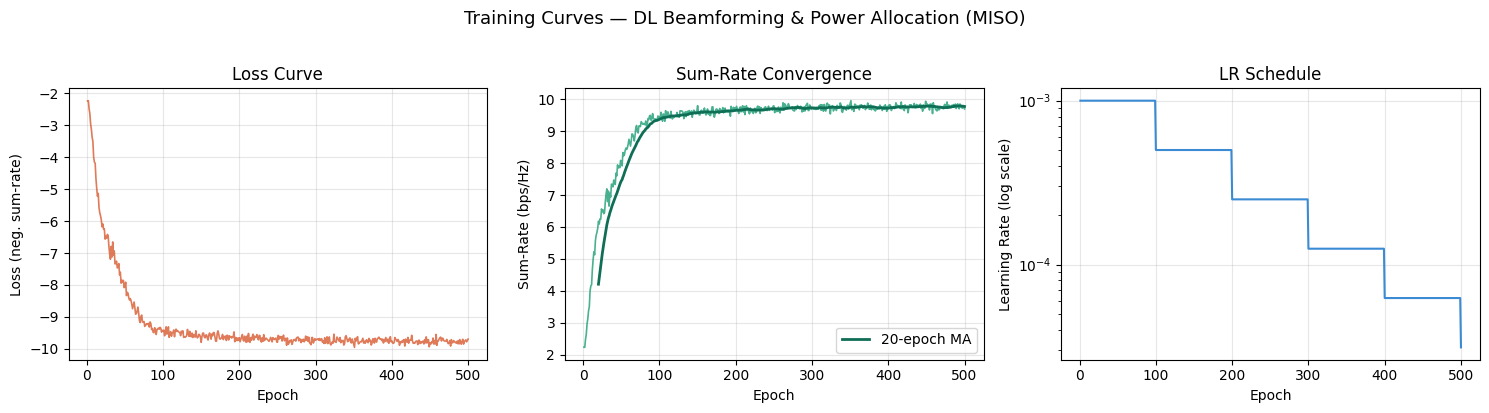

Saved training_curves.png


In [ ]:
epochs = np.arange(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Training Curves — DL Beamforming & Power Allocation (MISO)', fontsize=13, y=1.02)

# Loss
ax = axes[0]
ax.plot(epochs, loss_history, color='#D85A30', linewidth=1.2, alpha=0.8)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (neg. sum-rate)')
ax.set_title('Loss Curve')
ax.grid(True, alpha=0.3)

# Sum-rate
ax = axes[1]
ax.plot(epochs, sum_rate_history, color='#1D9E75', linewidth=1.2, alpha=0.8)
# Moving average
window = 20
ma = np.convolve(sum_rate_history, np.ones(window)/window, mode='valid')
ax.plot(epochs[window-1:], ma, color='#0F6E56', linewidth=2, label=f'{window}-epoch MA')
ax.set_xlabel('Epoch'); ax.set_ylabel('Sum-Rate (bps/Hz)')
ax.set_title('Sum-Rate Convergence')
ax.legend(); ax.grid(True, alpha=0.3)

# Learning rate
ax = axes[2]
ax.semilogy(epochs, lr_history, color='#3B8BD4', linewidth=1.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate (log scale)')
ax.set_title('LR Schedule')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved training_curves.png')

## 8. Evaluation on Test Channels

In [ ]:
def evaluate(model, num_test=2000):
    """Evaluate trained model on fresh test channels."""
    model.eval()
    all_rates = []
    all_powers = []
    all_sinr   = []

    with torch.no_grad():
        for _ in range(num_test // 256 + 1):
            h_real, h_cplx = generate_channel(256, K, Nt)
            beams, powers  = model(h_real)
            sinr           = compute_sinr(h_cplx, beams, powers, sigma2)
            rates          = torch.log2(1.0 + sinr)           # (batch, K)

            all_rates.append(rates.cpu().numpy())
            all_powers.append(powers.cpu().numpy())
            all_sinr.append(sinr.cpu().numpy())

    rates  = np.concatenate(all_rates,  axis=0)[:num_test]    # (N, K)
    powers = np.concatenate(all_powers, axis=0)[:num_test]    # (N, K)
    sinr   = np.concatenate(all_sinr,   axis=0)[:num_test]    # (N, K)

    return rates, powers, sinr


rates, powers, sinr_vals = evaluate(model)
sum_rates = rates.sum(axis=1)

print('=== Test Set Results (2000 channels) ===')
print(f'Mean sum-rate : {sum_rates.mean():.4f} bps/Hz')
print(f'Std  sum-rate : {sum_rates.std():.4f} bps/Hz')
print(f'Max  sum-rate : {sum_rates.max():.4f} bps/Hz')
print()
for k in range(K):
    print(f'  User {k+1}: mean rate = {rates[:,k].mean():.3f} bps/Hz | '
          f'mean SINR = {10*np.log10(sinr_vals[:,k].mean()):.2f} dB | '
          f'mean power = {powers[:,k].mean():.4f}')

=== Test Set Results (2000 channels) ===
Mean sum-rate : 9.7960 bps/Hz
Std  sum-rate : 1.1652 bps/Hz
Max  sum-rate : 12.7133 bps/Hz

  User 1: mean rate = 0.000 bps/Hz | mean SINR = -42.05 dB | mean power = 0.0001
  User 2: mean rate = 2.900 bps/Hz | mean SINR = 25.03 dB | mean power = 0.9000
  User 3: mean rate = 6.896 bps/Hz | mean SINR = 28.90 dB | mean power = 2.0999


## 9. Results Visualization

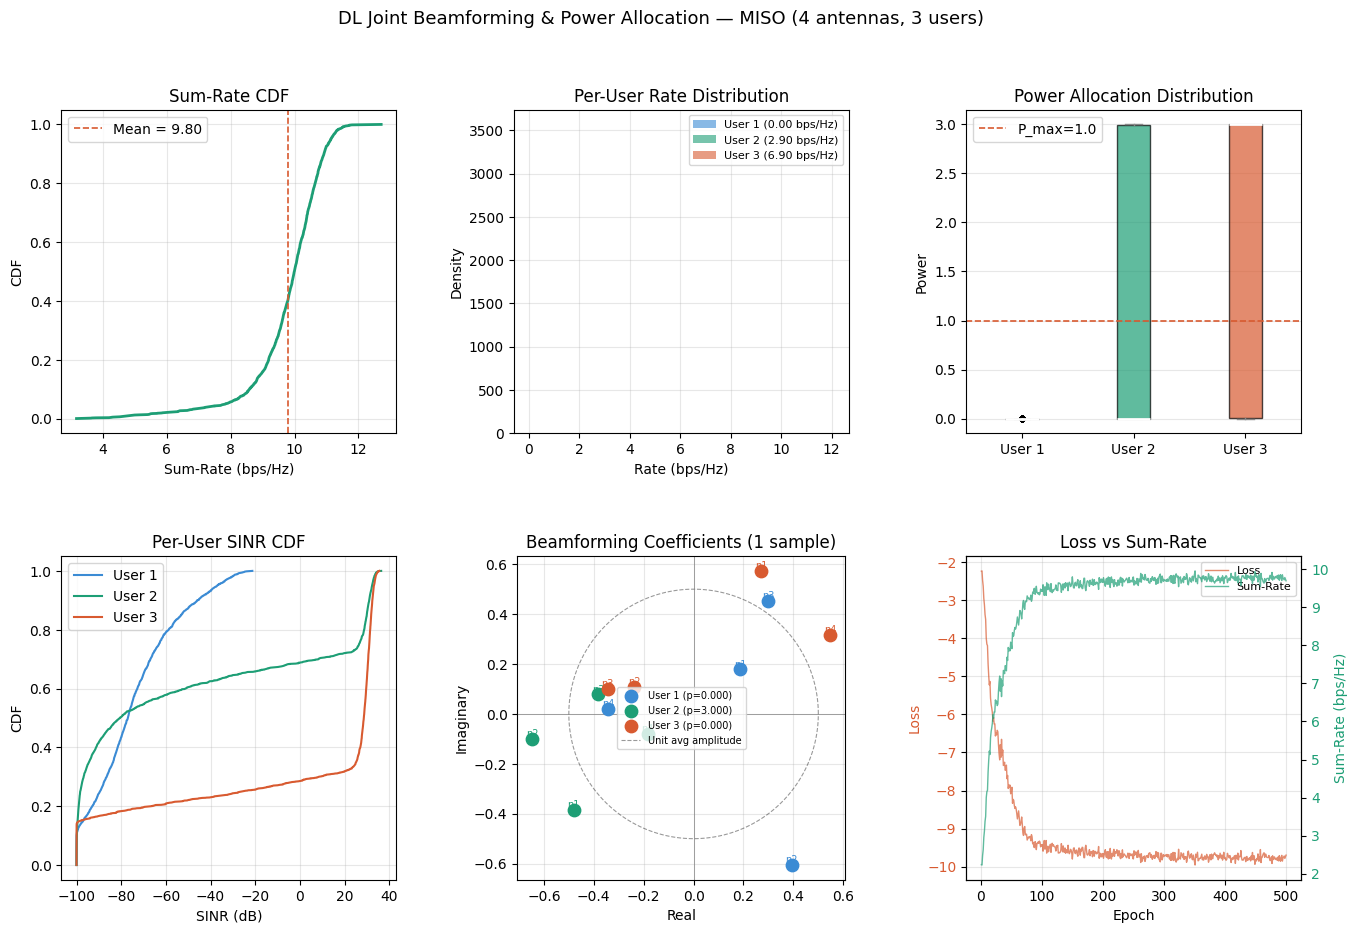

Saved results_summary.png


In [ ]:
USER_COLORS = ['#3B8BD4', '#1D9E75', '#D85A30', '#9F3FBF', '#E8A020', '#D04060']

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.35)
fig.suptitle(f'DL Joint Beamforming & Power Allocation — MISO ({Nt} antennas, {K} users)',
             fontsize=13, y=0.98)

# ── 1. Sum-rate CDF ────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
sorted_sr = np.sort(sum_rates)
cdf = np.arange(1, len(sorted_sr)+1) / len(sorted_sr)
ax1.plot(sorted_sr, cdf, color='#1D9E75', linewidth=2)
ax1.axvline(sorted_sr.mean(), color='#D85A30', linestyle='--', linewidth=1.2,
            label=f'Mean = {sorted_sr.mean():.2f}')
ax1.set_xlabel('Sum-Rate (bps/Hz)'); ax1.set_ylabel('CDF')
ax1.set_title('Sum-Rate CDF'); ax1.legend(); ax1.grid(True, alpha=0.3)

# ── 2. Per-user rate distribution ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
for k in range(K):
    ax2.hist(rates[:, k], bins=40, alpha=0.6, color=USER_COLORS[k],
             label=f'User {k+1} ({rates[:,k].mean():.2f} bps/Hz)', density=True)
ax2.set_xlabel('Rate (bps/Hz)'); ax2.set_ylabel('Density')
ax2.set_title('Per-User Rate Distribution'); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# ── 3. Power allocation box plot ───────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
bp = ax3.boxplot(powers, patch_artist=True, notch=False,
                 medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], USER_COLORS[:K]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
for whisker in bp['whiskers']: whisker.set_color('#888'); whisker.set_linewidth(1)
for cap in bp['caps']:         cap.set_color('#888'); cap.set_linewidth(1)
for flier in bp['fliers']:     flier.set_markerfacecolor('#ccc'); flier.set_markersize(3)
ax3.axhline(Pmax, color='#D85A30', linestyle='--', linewidth=1.2, label=f'P_max={Pmax}')
ax3.set_xticks(range(1, K+1)); ax3.set_xticklabels([f'User {k+1}' for k in range(K)])
ax3.set_ylabel('Power'); ax3.set_title('Power Allocation Distribution')
ax3.legend(); ax3.grid(True, alpha=0.3, axis='y')

# ── 4. SINR CDF per user ───────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
for k in range(K):
    sinr_dB = 10 * np.log10(sinr_vals[:, k] + 1e-10)
    sorted_s = np.sort(sinr_dB)
    cdf_s    = np.arange(1, len(sorted_s)+1) / len(sorted_s)
    ax4.plot(sorted_s, cdf_s, color=USER_COLORS[k], linewidth=1.5, label=f'User {k+1}')
ax4.set_xlabel('SINR (dB)'); ax4.set_ylabel('CDF')
ax4.set_title('Per-User SINR CDF'); ax4.legend(); ax4.grid(True, alpha=0.3)

# ── 5. Beamforming vectors in complex plane (first test sample) ────────────
ax5 = fig.add_subplot(gs[1, 1])
model.eval()
with torch.no_grad():
    h_r, h_c = generate_channel(1, K, Nt)
    bms, pws = model(h_r)
bms_np = bms[0].cpu().numpy()   # (K, Nt) complex
for k in range(K):
    ax5.scatter(bms_np[k].real, bms_np[k].imag, color=USER_COLORS[k],
                s=80, zorder=5, label=f'User {k+1} (p={pws[0,k].item():.3f})')
    for n in range(Nt):
        ax5.annotate(f'n{n+1}', (bms_np[k, n].real, bms_np[k, n].imag),
                     fontsize=7, ha='center', va='bottom', color=USER_COLORS[k])
theta = np.linspace(0, 2*np.pi, 200)
ax5.plot(np.cos(theta)/np.sqrt(Nt), np.sin(theta)/np.sqrt(Nt),
         'k--', linewidth=0.8, alpha=0.4, label='Unit avg amplitude')
ax5.axhline(0, color='gray', linewidth=0.5); ax5.axvline(0, color='gray', linewidth=0.5)
ax5.set_xlabel('Real'); ax5.set_ylabel('Imaginary')
ax5.set_title('Beamforming Coefficients (1 sample)'); ax5.legend(fontsize=7)
ax5.grid(True, alpha=0.3); ax5.set_aspect('equal')

# ── 6. Loss + Sum-rate on same axis (dual y) ───────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
color1, color2 = '#D85A30', '#1D9E75'
ax6.plot(epochs, loss_history, color=color1, linewidth=1, alpha=0.7, label='Loss')
ax6.set_xlabel('Epoch'); ax6.set_ylabel('Loss', color=color1)
ax6.tick_params(axis='y', labelcolor=color1)
ax6b = ax6.twinx()
ax6b.plot(epochs, sum_rate_history, color=color2, linewidth=1, alpha=0.7, label='Sum-Rate')
ax6b.set_ylabel('Sum-Rate (bps/Hz)', color=color2)
ax6b.tick_params(axis='y', labelcolor=color2)
ax6.set_title('Loss vs Sum-Rate')
lines1, labels1 = ax6.get_legend_handles_labels()
lines2, labels2 = ax6b.get_legend_handles_labels()
ax6.legend(lines1+lines2, labels1+labels2, fontsize=8)
ax6.grid(True, alpha=0.3)

plt.savefig('results_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved results_summary.png')

## 10. Benchmark: DL vs Equal Power Baseline

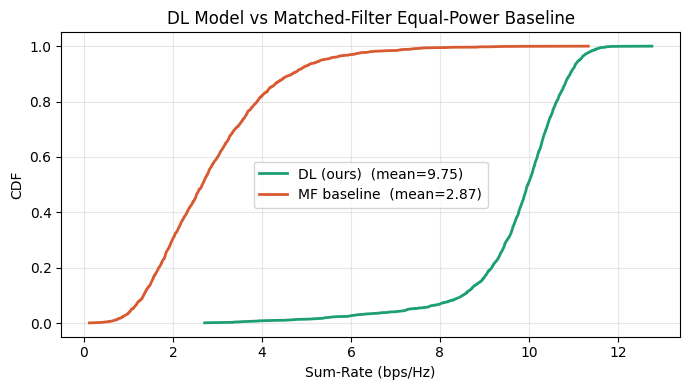

DL mean sum-rate : 9.7468 bps/Hz
MF mean sum-rate : 2.8694 bps/Hz
Gain of DL over MF: +239.7%


In [ ]:
def equal_power_baseline(H_cplx, sigma2, Pmax, K):
    """
    Baseline: equal power (Pmax per user) with matched-filter (MF) beamforming.
    MF beamformer for user k: w_k = h_k / ||h_k||  (conjugate beamforming)
    """
    # MF beams (conjugate of normalized channel)
    h_norm = H_cplx / H_cplx.norm(dim=2, keepdim=True).clamp(min=1e-8)
    beams  = h_norm.conj()                          # (batch, K, Nt)
    powers = torch.full((H_cplx.size(0), K), Pmax,
                        device=H_cplx.device)       # equal power
    sinr   = compute_sinr(H_cplx, beams, powers, sigma2)
    rates  = torch.log2(1.0 + sinr).sum(dim=1)     # sum-rate per sample
    return rates


# Test both on 2000 fresh channels
N_TEST = 2000
dl_sr_list, mf_sr_list = [], []

model.eval()
with torch.no_grad():
    for _ in range(N_TEST // 256 + 1):
        h_real, h_cplx = generate_channel(256, K, Nt)

        # DL model
        beams, powers = model(h_real)
        sinr_dl = compute_sinr(h_cplx, beams, powers, sigma2)
        dl_sr   = torch.log2(1.0 + sinr_dl).sum(1).cpu().numpy()

        # MF baseline
        mf_sr = equal_power_baseline(h_cplx, sigma2, Pmax, K).cpu().numpy()

        dl_sr_list.append(dl_sr)
        mf_sr_list.append(mf_sr)

dl_sr_arr = np.concatenate(dl_sr_list)[:N_TEST]
mf_sr_arr = np.concatenate(mf_sr_list)[:N_TEST]

fig, ax = plt.subplots(figsize=(7, 4))
for arr, label, color in [
    (dl_sr_arr, 'DL (ours)',  '#1D9E75'),
    (mf_sr_arr, 'MF baseline','#D85A30'),
]:
    s = np.sort(arr)
    c = np.arange(1, len(s)+1) / len(s)
    ax.plot(s, c, linewidth=2, label=f'{label}  (mean={arr.mean():.2f})', color=color)

ax.set_xlabel('Sum-Rate (bps/Hz)'); ax.set_ylabel('CDF')
ax.set_title('DL Model vs Matched-Filter Equal-Power Baseline')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

gain = (dl_sr_arr.mean() - mf_sr_arr.mean()) / mf_sr_arr.mean() * 100
print(f'DL mean sum-rate : {dl_sr_arr.mean():.4f} bps/Hz')
print(f'MF mean sum-rate : {mf_sr_arr.mean():.4f} bps/Hz')
print(f'Gain of DL over MF: {gain:+.1f}%')

## 11. SNR Sweep (Sum-Rate vs Pmax)

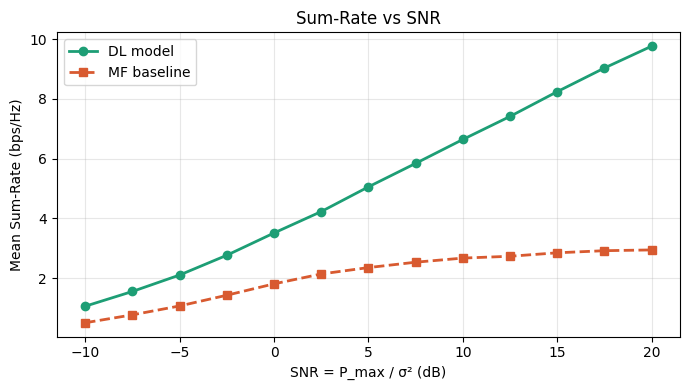

In [ ]:
# Note: this cell re-trains a lightweight model for each Pmax to show the SNR curve
# For a quick demo, we just run inference at different Pmax values and rescale powers

Pmax_dB_range = np.linspace(-10, 20, 13)     # dB relative to noise
Pmax_vals     = 10 ** (Pmax_dB_range / 10) * sigma2

dl_means, mf_means = [], []

model.eval()
N_EVAL = 1000
with torch.no_grad():
    for P in Pmax_vals:
        dl_srs, mf_srs = [], []
        for _ in range(N_EVAL // 256 + 1):
            h_real, h_cplx = generate_channel(256, K, Nt)

            # DL: rescale power output proportionally
            beams, powers = model(h_real)
            scale = P / Pmax
            powers_scaled = powers * scale
            sinr_dl = compute_sinr(h_cplx, beams, powers_scaled, sigma2)
            dl_srs.append(torch.log2(1+sinr_dl).sum(1).cpu().numpy())

            # MF baseline at same Pmax
            mf_sr = equal_power_baseline(h_cplx, sigma2, P, K).cpu().numpy()
            mf_srs.append(mf_sr)

        dl_means.append(np.concatenate(dl_srs)[:N_EVAL].mean())
        mf_means.append(np.concatenate(mf_srs)[:N_EVAL].mean())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(Pmax_dB_range, dl_means, 'o-', color='#1D9E75', linewidth=2, label='DL model')
ax.plot(Pmax_dB_range, mf_means, 's--', color='#D85A30', linewidth=2, label='MF baseline')
ax.set_xlabel('SNR = P_max / σ² (dB)'); ax.set_ylabel('Mean Sum-Rate (bps/Hz)')
ax.set_title('Sum-Rate vs SNR')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('snr_curve.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. Save & Load Model

In [ ]:
# Save model weights
torch.save({
    'model_state_dict'    : model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch'               : NUM_EPOCHS,
    'sum_rate_history'    : sum_rate_history,
    'loss_history'        : loss_history,
    'config': {
        'Nt': Nt, 'K': K, 'Pmax': Pmax, 'sigma2': sigma2,
        'hidden_dim': HIDDEN_DIM, 'num_hidden': NUM_HIDDEN,
    }
}, 'beamforming_model.pt')
print('Model saved to beamforming_model.pt')

# Load and verify
checkpoint = torch.load('beamforming_model.pt', map_location=device)
cfg = checkpoint['config']
model_loaded = BeamformingNet(
    input_dim  = 2 * cfg['K'] * cfg['Nt'],
    hidden_dim = cfg['hidden_dim'],
    num_hidden = cfg['num_hidden'],
    K=cfg['K'], Nt=cfg['Nt'], Pmax=cfg['Pmax']
).to(device)
model_loaded.load_state_dict(checkpoint['model_state_dict'])
model_loaded.eval()

# Quick inference test
with torch.no_grad():
    h_r, h_c = generate_channel(16, K, Nt)
    bms, pws = model_loaded(h_r)
    _, sr = sum_rate_loss(h_c, bms, pws, sigma2)
print(f'Loaded model sum-rate (16 samples): {sr:.4f} bps/Hz ')

Model saved to beamforming_model.pt
Loaded model sum-rate (16 samples): 9.6724 bps/Hz 
